## Plotting the relationship between service time and batch size

In [8]:
%pip install -q pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [9]:
import glob, os, re
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
csv_files = sorted(glob.glob("const_b*.csv")) 

records = []
for fp in csv_files:
    df = pd.read_csv(fp)
    service_time = df.iloc[0]["Server Compute Infer"]  # first row only
    batch_size = int(re.search(r"_b(\d+)", os.path.basename(fp)).group(1))
    records.append({"filename": os.path.basename(fp),
                    "batch_size": batch_size,
                    "service_time": service_time})


In [11]:
# Create DataFrame and sort by batch size
df_plot = pd.DataFrame(records).sort_values("batch_size").reset_index(drop=True)
display(df_plot)

,filename,batch_size,service_time
0,const_b8.csv,8,1165.0
1,const_b10.csv,10,1323.0
2,const_b12.csv,12,1469.0
3,const_b14.csv,14,1625.0
4,const_b16.csv,16,1788.0
5,const_b18.csv,18,1958.0
6,const_b20.csv,20,2117.0
7,const_b22.csv,22,2292.0
8,const_b24.csv,24,2457.0
9,const_b26.csv,26,2605.0


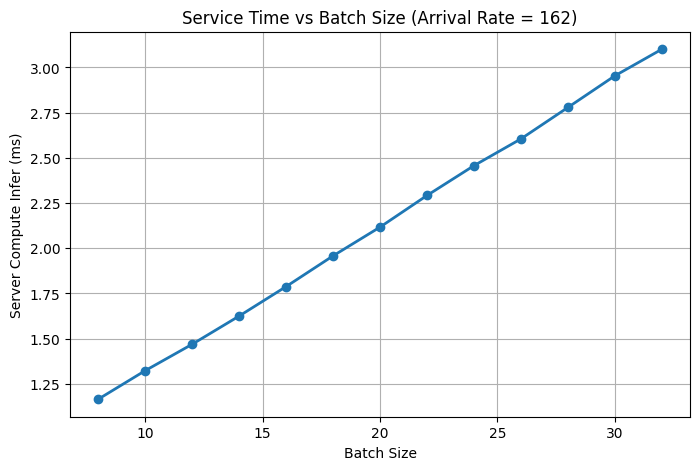

In [12]:
plt.figure(figsize=(8,5))
plt.plot(df_plot["batch_size"], df_plot["service_time"]/1000, marker="o", linewidth=2)
plt.xlabel("Batch Size")
plt.ylabel("Server Compute Infer (ms)")
plt.title("Service Time vs Batch Size (Arrival Rate = 162)")
plt.grid(True)
plt.show()